In [1]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv

from langchain_openai import ChatOpenAI
from langchain_core.messages.utils import trim_messages,count_tokens_approximately

In [2]:
load_dotenv()

True

In [11]:
load_dotenv()
from langchain_groq import ChatGroq
# Model
model = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0.1)

In [4]:
MAX_TOKENS = 150

In [5]:
def call_model(state: MessagesState):
    
    # Trim conversation history -> last N messages that fit within the token budget
    messages = trim_messages(
        state["messages"],
        strategy="last",                      
        token_counter=count_tokens_approximately,
        max_tokens=MAX_TOKENS
    )

    print('Current Token Count ->', count_tokens_approximately(messages=messages))

    for message in messages:
        print(message.content)

    response = model.invoke(messages)

    return {"messages": [response]}

In [6]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

In [7]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

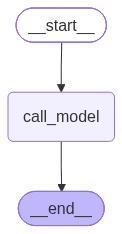

In [8]:
graph

In [12]:
config = {"configurable": {"thread_id": "chat-1"}}

result = graph.invoke(
    {"messages": [{"role": "user", "content": "Hi, my name is Sujat."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 30
Hi, my name is Sujat.
Hi, my name is Sujat.
Hi, my name is Sujat.


'Hello Sujat! Nice to meet you. How can I assist you today?'

In [13]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "I am learning LangGraph."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 60
Hi, my name is Sujat.
Hi, my name is Sujat.
Hi, my name is Sujat.
Hello Sujat! Nice to meet you. How can I assist you today?
I am learning LangGraph.


'That’s great! LangGraph is a powerful framework for building composable, state‑driven LLM applications. Here’s a quick roadmap to get you up to speed, plus some hands‑on examples you can try right away.\n\n---\n\n## 1️⃣ Core Concepts at a Glance\n\n| Concept | What It Is | Why It Matters |\n|---------|------------|----------------|\n| **Node** | A reusable “step” that can call an LLM, run a tool, or perform any Python logic. | Encapsulates a single piece of functionality. |\n| **Edge** | A directed connection that tells the graph how to move from one node to the next, optionally based on conditions. | Enables branching, loops, and dynamic flow. |\n| **State** | A mutable dictionary (or Pydantic model) that travels with the graph, holding inputs, intermediate results, and metadata. | Gives every node access to the same context, making coordination easy. |\n| **Graph** | The orchestrator that wires nodes & edges together and runs the execution loop. | Turns a collection of isolated func

In [14]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "Can you explain short term memory?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 13
Can you explain short term memory?


'**Short‑term memory (STM)** is a mental system that holds a small amount of information in an active, readily accessible state for a brief period of time—typically on the order of seconds to a minute. It’s the “scratch‑pad” of the brain that lets you keep track of what you’re doing right now, such as remembering a phone number long enough to dial it or holding the last few words of a sentence while you understand its meaning.\n\nBelow is a concise overview of the key features, mechanisms, and practical implications of short‑term memory.\n\n---\n\n## 1. Core Characteristics\n\n| Feature | Typical Value | What It Means |\n|---------|----------------|----------------|\n| **Capacity** | 7\u202f±\u202f2 items (Miller’s classic estimate) | Most people can hold about 5–9 discrete “chunks” of information at once. A “chunk” can be a single digit, a word, or a meaningful group (e.g., a familiar acronym). |\n| **Duration** | 15–30\u202fseconds without rehearsal | If you don’t actively repeat or 

In [15]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "What is my name?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 8
What is my name?


'I don’t have any information about your name. If you’d like me to address you a certain way, just let me know!'

In [16]:
for item in graph.get_state({"configurable": {"thread_id": "chat-1"}}).values['messages']:
    print(item.content)
    print('-'*120)

Hi, my name is Sujat.
------------------------------------------------------------------------------------------------------------------------
Hi, my name is Sujat.
------------------------------------------------------------------------------------------------------------------------
Hi, my name is Sujat.
------------------------------------------------------------------------------------------------------------------------
Hello Sujat! Nice to meet you. How can I assist you today?
------------------------------------------------------------------------------------------------------------------------
I am learning LangGraph.
------------------------------------------------------------------------------------------------------------------------
That’s great! LangGraph is a powerful framework for building composable, state‑driven LLM applications. Here’s a quick roadmap to get you up to speed, plus some hands‑on examples you can try right away.

---

## 1️⃣ Core Concepts at a Glance

| 